# Проект: классификация

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [95]:
df = pd.read_csv('bank_fin.csv', sep = ';')

In [99]:
print(df.isna().sum())
print(df.isna().sum().sort_values(ascending=False))

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64
balance      25
age           0
job           0
education     0
marital       0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64


### Задание 2

In [87]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
# ваш код
df['job'].value_counts(dropna=False)

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

### Задание 3

In [101]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)

#  Преобразуем balance в float
df['balance'] = (df['balance']
                 .replace(r'\s*\$\s*', '', regex=True)  # удаляем $
                 .replace(r'\s+', '', regex=True)       # удаляем пробелы (разделители тысяч)
                 .replace(',', '.', regex=True)         # заменяем запятую на точку
                 .astype(float))

#  Вычисляем среднее значение
mean_balance = df['balance'].mean()
print(f"Среднее значение balance: {mean_balance}")
print(f"Округлённый ответ: {round(mean_balance, 3)}")

Среднее значение balance: 1529.1290293615875
Округлённый ответ: 1529.129


### Задание 4

In [102]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку

#  Находим медиану по balance (без пропусков)
median_balance = df['balance'].median()
print(f"Медиана balance: {median_balance}")

# Заменяем пропуски на медиану
df['balance'] = df['balance'].fillna(median_balance)

# Вычисляем новое среднее значение
mean_balance_filled = df['balance'].mean()
print(f"Среднее значение после заполнения пропусков: {mean_balance_filled}")
print(f"Округлённый ответ: {round(mean_balance_filled, 3)}")

Медиана balance: 550.0
Среднее значение после заполнения пропусков: 1526.9360329690019
Округлённый ответ: 1526.936


### Задание 5

In [105]:
# 1. Заменяем 'unknown' в job на моду
mode_job = df['job'].mode()[0]  # 'management'
df['job'] = df['job'].replace('unknown', mode_job)

# 2. Заменяем 'unknown' в education на моду
mode_education = df['education'].mode()[0]  # 'secondary'
df['education'] = df['education'].replace('unknown', mode_education)

# 3. Фильтруем: job == mode_job И education == mode_education
mask = (df['job'] == mode_job) & (df['education'] == mode_education)
mean_balance_subset = df.loc[mask, 'balance'].mean()

print(f"Самая популярная работа (мода job): {mode_job}")
print(f"Самое популярное образование (мода education): {mode_education}")
print(f"Количество клиентов с этой комбинацией: {mask.sum()}")
print(f"Средний баланс для этой группы: {mean_balance_subset}")
print(f"Округлённый ответ: {round(mean_balance_subset, 3)}")

Самая популярная работа (мода job): management
Самое популярное образование (мода education): secondary
Количество клиентов с этой комбинацией: 376
Средний баланс для этой группы: 1598.8829787234042
Округлённый ответ: 1598.883


### Задание 6

In [106]:
import numpy as np

# 1. Вычисляем квартили и IQR
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

# 2. Вычисляем границы
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Нижняя граница: {lower_bound}")
print(f"Верхняя граница: {upper_bound}")
print(f"Нижняя граница (округлённая до целых): {round(lower_bound)}")
print(f"Верхняя граница (округлённая до целых): {round(upper_bound)}")

Q1 = 123.0
Q3 = 1699.0
IQR = 1576.0
Нижняя граница: -2241.0
Верхняя граница: 4063.0
Нижняя граница (округлённая до целых): -2241
Верхняя граница (округлённая до целых): 4063


In [107]:
# Фильтруем данные: оставляем только те, где balance в пределах границ
mask_no_outliers = (df['balance'] >= -2241) & (df['balance'] <= 4063)
df_no_outliers = df[mask_no_outliers]

print(f"Количество объектов после удаления выбросов: {len(df_no_outliers)}")
print(f"Изначальное количество объектов: {len(df)}")
print(f"Количество удалённых выбросов: {len(df) - len(df_no_outliers)}")

Количество объектов после удаления выбросов: 10105
Изначальное количество объектов: 11162
Количество удалённых выбросов: 1057


## Часть 2:  Разведывательный анализ

### Задание 1

In [113]:
# Проверим, на каком датафрейме мы работаем
print(f"Длина df: {len(df)}")

# Если есть df_no_outliers, проверим его
try:
    print(f"Длина df_no_outliers: {len(df_no_outliers)}")
    print(f"\nРаспределение deposit в df_no_outliers:")
    print(df_no_outliers['deposit'].value_counts())
    print(f"\nОткрыли депозит в df_no_outliers: {(df_no_outliers['deposit'] == 'yes').sum()}")
except:
    print("df_no_outliers не существует")

Длина df: 11162
Длина df_no_outliers: 10105

Распределение deposit в df_no_outliers:
deposit
no     5424
yes    4681
Name: count, dtype: int64

Открыли депозит в df_no_outliers: 4681


### Задания 2 и 3

In [114]:
# Описательные статистики для всех количественных переменных
print(df.describe())

# Максимальный возраст
print(f"\nМаксимальный возраст: {df['age'].max()}")

# Минимальная продолжительность разговора (duration)
print(f"Минимальная продолжительность разговора (сек): {df['duration'].min()}")

                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1526.936033     15.658036    371.993818      2.508421   
std       11.913369   3224.829691      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    123.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1699.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       20.750000      1.000000  


### Задания 4 и 5

In [115]:
# Описательные статистики для категориальных переменных
print(df.describe(include='object'))

# Уникальные значения для month (месяцы маркетинговой кампании)
print("\nУникальные месяцы:")
print(df['month'].unique())
print(f"Количество уникальных месяцев: {df['month'].nunique()}")

# Уникальные значения для job (сферы занятости)
print("\nУникальные сферы занятости (job):")
print(df['job'].unique())
print(f"Количество сфер занятости: {df['job'].nunique()}")

               job  marital  education default housing   loan   contact  \
count        11162    11162      11162   11162   11162  11162     11162   
unique          11        3          3       2       2      2         3   
top     management  married  secondary      no      no     no  cellular   
freq          2636     6351       5973   10994    5881   9702      8042   

        month poutcome deposit  
count   11162    11162   11162  
unique     12        4       2  
top       may  unknown      no  
freq     2824     8326    5873  

Уникальные месяцы:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Количество уникальных месяцев: 12

Уникальные сферы занятости (job):
['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'self-employed' 'student']
Количество сфер занятости: 11


### Задание 6

In [116]:
# Группируем по poutcome и считаем value_counts для deposit
print(df.groupby('poutcome')['deposit'].value_counts())

# Или в виде таблицы
print("\nВ виде таблицы:")
print(df.groupby('poutcome')['deposit'].value_counts().unstack(fill_value=0))

poutcome  deposit
failure   yes         618
          no          610
other     yes         307
          no          230
success   yes         978
          no           93
unknown   no         4940
          yes        3386
Name: count, dtype: int64

В виде таблицы:
deposit     no   yes
poutcome            
failure    610   618
other      230   307
success     93   978
unknown   4940  3386


### Задание 7

In [117]:
# Группируем по month и считаем проценты неудач
result = df.groupby('month')['deposit'].value_counts(normalize=True).unstack(fill_value=0)
result['fail_rate'] = result['no'] * 100  # процент неудач

print("Процент неудач по месяцам:")
print(result[['no', 'fail_rate']].sort_values('fail_rate', ascending=False))

# Находим месяц с самым большим процентом неудач
max_fail_month = result['fail_rate'].idxmax()
print(f"\nМесяц с самым большим процентом неудач: {max_fail_month}")
print(f"Процент неудач в этом месяце: {result.loc[max_fail_month, 'fail_rate']:.2f}%")

Процент неудач по месяцам:
deposit        no  fail_rate
month                       
may      0.672450  67.245042
jan      0.587209  58.720930
jul      0.585865  58.586526
nov      0.572641  57.264051
jun      0.553191  55.319149
aug      0.547070  54.707044
feb      0.431701  43.170103
apr      0.374865  37.486457
oct      0.176020  17.602041
sep      0.156740  15.673981
mar      0.101449  10.144928
dec      0.090909   9.090909

Месяц с самым большим процентом неудач: may
Процент неудач в этом месяце: 67.25%


### Задание 8

In [118]:
import pandas as pd

# Создаём возрастные группы
bins = [0, 30, 40, 50, 60, 100]
labels = ['<30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Считаем долю открытых депозитов по возрастным группам
result = df.groupby('age_group')['deposit'].value_counts(normalize=True).unstack(fill_value=0)
result['yes_rate'] = result['yes'] * 100  # процент открывших депозит

print("Доля открытых депозитов по возрастным группам:")
print(result[['yes', 'no', 'yes_rate']].sort_values('yes_rate', ascending=False))

# Находим группы, где yes > no (доля открывших > 50%)
print("\nГруппы, где открывших депозит больше, чем отказавшихся:")
print(result[result['yes'] > result['no']])

Доля открытых депозитов по возрастным группам:
deposit         yes        no   yes_rate
age_group                               
60+        0.769231  0.230769  76.923077
<30        0.598324  0.401676  59.832366
30-40      0.443029  0.556971  44.302918
50-60      0.416446  0.583554  41.644562
40-50      0.404490  0.595510  40.449011

Группы, где открывших депозит больше, чем отказавшихся:
deposit          no       yes   yes_rate
age_group                               
<30        0.401676  0.598324  59.832366
60+        0.230769  0.769231  76.923077


### Задания 9 и 10

In [121]:
# Задание 3.9: сфера занятости с наибольшим числом клиентов
print("Задание 3.9: Распределение по сфере занятости (job):")
print(df['job'].value_counts())
print(f"\nНаибольшее число клиентов в сфере: {df['job'].value_counts().idxmax()}")

# Задание 3.10: семейное положение и тенденция открывать депозит
print("\n\nЗадание 3.10: Анализ по семейному положению (marital):")
result_marital = df.groupby('marital')['deposit'].value_counts(normalize=True).unstack(fill_value=0)
print(result_marital)
print("\nДоля открывших депозит по семейному положению:")
print(result_marital['yes'].sort_values(ascending=False))

# Находим, где yes > no (тенденция открывать)
print("\nГруппы, где тенденция открывать депозит (yes > no):")
print(result_marital[result_marital['yes'] > result_marital['no']])

Задание 3.9: Распределение по сфере занятости (job):
job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
Name: count, dtype: int64

Наибольшее число клиентов в сфере: management


Задание 3.10: Анализ по семейному положению (marital):
deposit         no       yes
marital                     
divorced  0.518948  0.481052
married   0.566210  0.433790
single    0.456509  0.543491

Доля открывших депозит по семейному положению:
marital
single      0.543491
divorced    0.481052
married     0.433790
Name: yes, dtype: float64

Группы, где тенденция открывать депозит (yes > no):
deposit        no       yes
marital                    
single   0.456509  0.543491


In [ ]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования

In [ ]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости

### Задание 11

In [123]:
import pandas as pd

# Общее пересечение (без разделения на deposit)
pivot_all = pd.crosstab(df['education'], df['marital'])
print("Общее распределение (education × marital):")
print(pivot_all)

# Находим максимальное значение
max_val = pivot_all.values.max()
print(f"\nМаксимальное количество: {max_val}")

# Находим индексы максимального значения
max_positions = (pivot_all == max_val)
print("\nПозиции максимального значения:")
print(max_positions)

# Выводим название категории
for edu in pivot_all.index:
    for mar in pivot_all.columns:
        if pivot_all.loc[edu, mar] == max_val:
            print(f"\nСамая многочисленная группа: education={edu}, marital={mar} ({max_val} человек)")

Общее распределение (education × marital):
marital    divorced  married  single
education                           
primary         204     1099     197
secondary       703     3409    1861
tertiary        386     1843    1460

Максимальное количество: 3409

Позиции максимального значения:
marital    divorced  married  single
education                           
primary       False    False   False
secondary     False     True   False
tertiary      False    False   False

Самая многочисленная группа: education=secondary, marital=married (3409 человек)


## Часть 3: преобразование данных

### Задание 1

In [127]:
from sklearn.preprocessing import LabelEncoder

# Пробуем на df_no_outliers
le = LabelEncoder()
encoded = le.fit_transform(df_no_outliers['education'])

print("Уникальные значения education в df_no_outliers:")
print(df_no_outliers['education'].unique())
print("\nСоответствие категорий и кодов:")
for i, category in enumerate(le.classes_):
    print(f"{category} -> {i}")

print(f"\nСумма закодированных значений: {encoded.sum()}")
print(f"Количество записей: {len(encoded)}")

Уникальные значения education в df_no_outliers:
['secondary' 'tertiary' 'primary']

Соответствие категорий и кодов:
primary -> 0
secondary -> 1
tertiary -> 2

Сумма закодированных значений: 11995
Количество записей: 10105


### Задания 2 и 3

In [128]:
from sklearn.preprocessing import LabelBinarizer

# Кодируем deposit: yes -> 1, no -> 0
lb = LabelBinarizer()
lb.fit(['no', 'yes'])  # фиксируем порядок: no=0, yes=1
df['deposit_encoded'] = lb.transform(df['deposit'])

print("Уникальные значения deposit_encoded:")
print(df['deposit_encoded'].unique())
print(f"\nКоличество 1 (yes): {(df['deposit_encoded'] == 1).sum()}")
print(f"Количество 0 (no): {(df['deposit_encoded'] == 0).sum()}")

# Вычисляем стандартное отклонение
std_deposit = df['deposit_encoded'].std()
print(f"\nСтандартное отклонение deposit_encoded: {std_deposit}")
print(f"Округлённый ответ: {round(std_deposit, 3)}")

Уникальные значения deposit_encoded:
[1 0]

Количество 1 (yes): 5289
Количество 0 (no): 5873

Стандартное отклонение deposit_encoded: 0.4993375439121514
Округлённый ответ: 0.499


In [130]:
from sklearn.preprocessing import LabelBinarizer

# Кодируем бинарные переменные на df_no_outliers
for col in ['default', 'housing', 'loan']:
    df_no_outliers[col + '_encoded'] = (df_no_outliers[col] == 'yes').astype(int)

# Вычисляем среднее для каждой
mean_default = df_no_outliers['default_encoded'].mean()
mean_housing = df_no_outliers['housing_encoded'].mean()
mean_loan = df_no_outliers['loan_encoded'].mean()

print(f"Среднее default_encoded: {mean_default}")
print(f"Среднее housing_encoded: {mean_housing}")
print(f"Среднее loan_encoded: {mean_loan}")

# Сумма средних
sum_means = mean_default + mean_housing + mean_loan
print(f"\nСумма средних: {sum_means}")
print(f"Округлённый ответ: {round(sum_means, 3)}")

Среднее default_encoded: 0.016427511133102424
Среднее housing_encoded: 0.4811479465611084
Среднее loan_encoded: 0.13785254824344384

Сумма средних: 0.6354280059376547
Округлённый ответ: 0.635


### Задание 4

In [134]:
feature_cols = [col for col in df_dummies.columns if col != 'deposit']
print(f"Количество признаков (без 'deposit'): {len(feature_cols)}")

Количество признаков (без 'deposit'): 50


### Задания 5 и 6

Числовые колонки:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'education_encoded', 'deposit_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded']


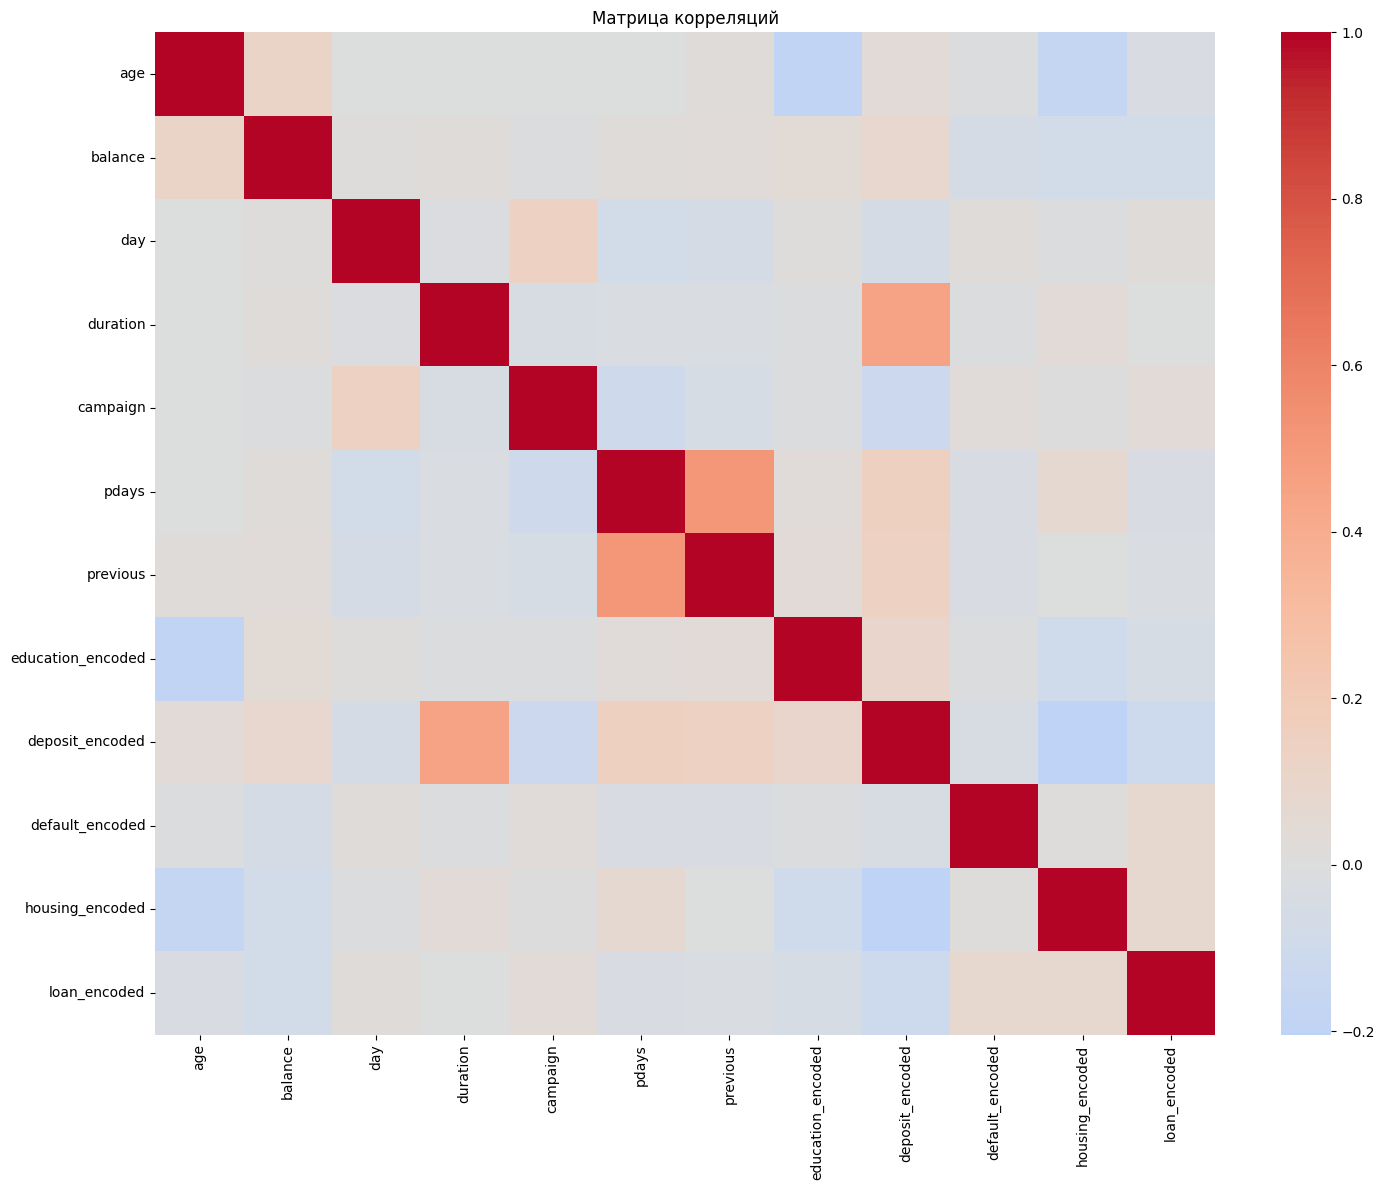


Корреляции с deposit_encoded (по убыванию):
duration             0.451919
pdays                0.151593
previous             0.139867
education_encoded    0.101049
balance              0.081150
age                  0.034901
default_encoded     -0.040680
day                 -0.056326
loan_encoded        -0.110580
campaign            -0.128081
housing_encoded     -0.203888
Name: deposit_encoded, dtype: float64

Топ-10 по абсолютному значению корреляции:
duration             0.451919
housing_encoded      0.203888
pdays                0.151593
previous             0.139867
campaign             0.128081
loan_encoded         0.110580
education_encoded    0.101049
balance              0.081150
day                  0.056326
default_encoded      0.040680
Name: deposit_encoded, dtype: float64


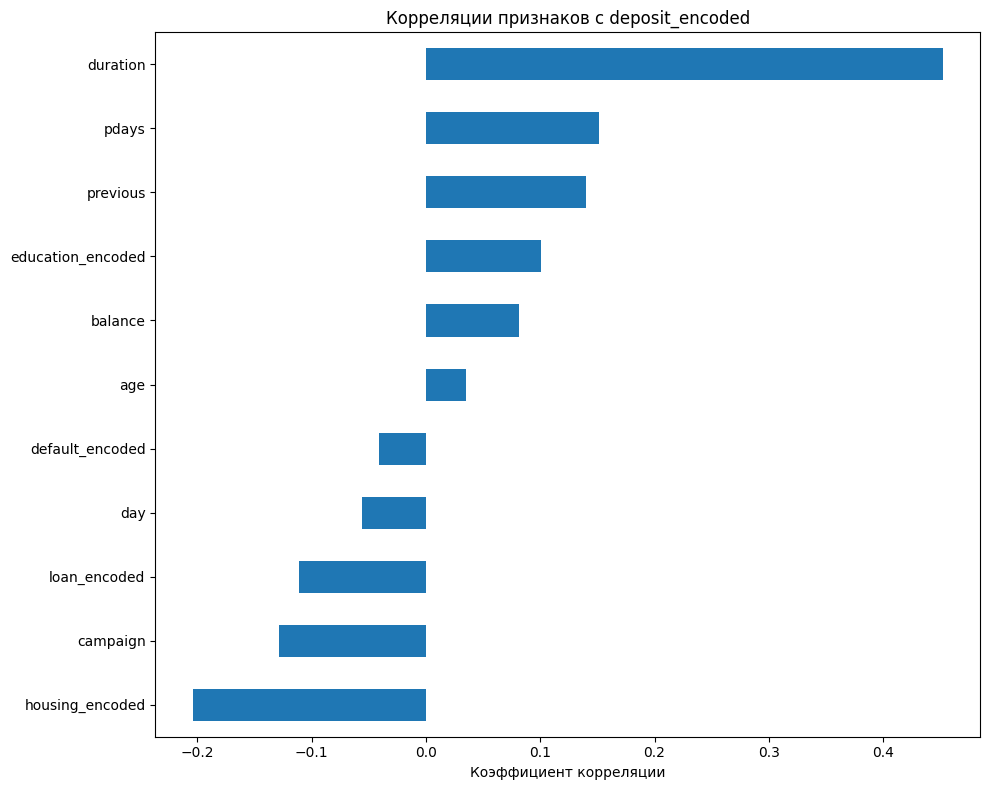

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

# Оставляем только числовые колонки
df_numeric = df_dummies.select_dtypes(include=['number'])

print("Числовые колонки:")
print(df_numeric.columns.tolist())

# Матрица корреляций
corr_matrix = df_numeric.corr()

# Тепловая карта
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

# Корреляции с целевой переменной (deposit_encoded)
corr_with_target = corr_matrix['deposit_encoded'].drop('deposit_encoded').sort_values(ascending=False)

print("\nКорреляции с deposit_encoded (по убыванию):")
print(corr_with_target)

# Топ-10 по абсолютному значению
print("\nТоп-10 по абсолютному значению корреляции:")
print(corr_with_target.abs().sort_values(ascending=False).head(10))

# Столбчатая диаграмма
plt.figure(figsize=(10, 8))
corr_with_target.sort_values().plot(kind='barh')
plt.title('Корреляции признаков с deposit_encoded')
plt.xlabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

In [138]:
# Проверяем максимальную корреляцию между признаками (без целевой переменной)
corr_no_target = corr_matrix.drop(columns=['deposit_encoded']).drop(index=['deposit_encoded'])

# Находим максимальную корреляцию (исключая диагональ)
import numpy as np
np.fill_diagonal(corr_no_target.values, 0)  # обнуляем диагональ

max_corr = corr_no_target.abs().max().max()
print(f"Максимальная корреляция между признаками: {max_corr}")

# Находим пары с корреляцией >= 0.9
high_corr_pairs = []
for i in range(len(corr_no_target.columns)):
    for j in range(i+1, len(corr_no_target.columns)):
        col1 = corr_no_target.columns[i]
        col2 = corr_no_target.columns[j]
        corr_val = corr_no_target.iloc[i, j]
        if abs(corr_val) >= 0.9:
            high_corr_pairs.append((col1, col2, corr_val))

print(f"\nПары с корреляцией >= 0.9: {high_corr_pairs}")

Максимальная корреляция между признаками: 0.5072715883726697

Пары с корреляцией >= 0.9: []


### Задания 7 и 8

In [3]:
X = df.drop(['deposit'], axis=1)
y = df['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [141]:
from sklearn.model_selection import train_test_split

# С df_no_outliers_dummies
X = df_no_outliers_dummies.drop(['deposit'], axis=1)
y = df_no_outliers_dummies['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    stratify=y, 
    random_state=42, 
    test_size=0.33
)

print(f"Размер тестовой выборки: {len(X_test)}")
mean_test = (y_test == 'yes').mean()
print(f"Среднее y_test: {mean_test}")
print(f"Округлённое: {round(mean_test, 2)}")

Размер тестовой выборки: 3335
Среднее y_test: 0.46326836581709147
Округлённое: 0.46


### Задание 9

In [150]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

# Используем df_dummies
df_temp = df_dummies.copy()

# Удаляем deposit и age_group (строковые)
df_temp = df_temp.drop(columns=['deposit', 'age_group'], errors='ignore')

# Преобразуем education (строковый) в числовой через get_dummies или удалим
df_temp = df_temp.drop(columns=['education'], errors='ignore')

# Преобразуем булевы колонки в int
for col in df_temp.columns:
    if df_temp[col].dtype == 'bool':
        df_temp[col] = df_temp[col].astype(int)

# Оставляем только числовые колонки
df_numeric = df_temp.select_dtypes(include=['number'])

print(f"Числовые колонки ({len(df_numeric.columns)}):")
print(df_numeric.columns.tolist())

# Целевая переменная и предикторы
X = df_numeric.drop(['deposit_encoded'], axis=1)
y = df_numeric['deposit_encoded']

print(f"\nРазмер X: {X.shape}")

# SelectKBest (k=min(15, n_features))
k = min(15, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    stratify=y, 
    random_state=42, 
    test_size=0.33
)
X_train_selected = selector.fit_transform(X_train, y_train)

# Получаем имена отобранных признаков
selected_features = X.columns[selector.get_support()]
print(f"\nОтобранные {k} признаков:")
print(selected_features.tolist())

# Проверяем month_* признаки
month_features = [col for col in X.columns if col.startswith('month_')]
print(f"\nВсе month_* признаки:")
print(month_features)

month_selected = [col for col in selected_features if col.startswith('month_')]
print(f"\nОтобранные month_* признаки:")
print(month_selected)

month_not_selected = [col for col in month_features if col not in selected_features]
print(f"\nmonth_* признаки, НЕ попавшие в выборку:")
print(month_not_selected)

Числовые колонки (45):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'education_encoded', 'deposit_encoded', 'default_encoded', 'housing_encoded', 'loan_encoded', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']

Размер X: (11162, 44)

Отобранные 15 признаков:
['duration', 'campaign', 'pdays', 'previous', 'housing_encoded', 'loan_encoded', 'job_blue-collar', 'contact_cellular', 'contact_unknown', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_

### Задание 10

In [158]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

# Используем df_no_outliers_dummies
df_temp = df_no_outliers_dummies.copy()

# Удаляем строковые колонки
df_temp = df_temp.drop(columns=['education', 'default', 'housing', 'loan', 'deposit'], errors='ignore')

# Преобразуем булевы колонки в int
for col in df_temp.columns:
    if df_temp[col].dtype == 'bool':
        df_temp[col] = df_temp[col].astype(int)

# Целевая переменная из оригинального df_no_outliers_dummies
y = df_no_outliers_dummies['deposit']
X = df_temp

print(f"Признаки ({len(X.columns)}): {X.columns.tolist()[:10]}...")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    stratify=y, 
    random_state=42, 
    test_size=0.33
)

# Отбор признаков
selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Нормализация
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train_selected)
X_test_norm = scaler.transform(X_test_selected)

# Первый предиктор из тестовой выборки
first_pred = X_test_norm[:, 0]
selected_features = X.columns[selector.get_support()]

print(f"\nОтобранные признаки: {selected_features.tolist()}")
print(f"Первый признак: {selected_features[0]}")
print(f"Среднее: {first_pred.mean()}")
print(f"Округлённое: {round(first_pred.mean(), 2)}")

Признаки (43): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'default_encoded', 'housing_encoded', 'loan_encoded']...

Отобранные признаки: ['balance', 'duration', 'campaign', 'pdays', 'previous', 'housing_encoded', 'loan_encoded', 'contact_cellular', 'contact_unknown', 'month_mar', 'month_may', 'month_oct', 'month_sep', 'poutcome_success', 'poutcome_unknown']
Первый признак: balance
Среднее: 0.46823674223097866
Округлённое: 0.47


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [159]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Используем нормализованные данные после отбора признаков
# X_train_norm, X_test_norm, y_train, y_test из предыдущего шага

# Создаём модель
model = LogisticRegression(
    solver='sag',
    random_state=42,
    max_iter=1000
)

# Обучаем
model.fit(X_train_norm, y_train)

# Предсказываем на тесте
y_pred = model.predict(X_test_norm)

# Вычисляем accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy на тестовой выборке: {acc}")
print(f"Округлённое до 2 знаков: {round(acc, 2)}")

Accuracy на тестовой выборке: 0.8041979010494753
Округлённое до 2 знаков: 0.8


### Задания 2,3,4

In [162]:
import numpy as np

# Находим глубину с максимальным test accuracy
depths = list(range(1, 21))
test_accs = [0.706, 0.718, 0.770, 0.770, 0.794, 0.804, 0.804, 0.804, 0.797, 0.802, 0.802, 0.796, 0.792, 0.793, 0.778, 0.776, 0.769, 0.767, 0.767, 0.763]

max_test_acc = max(test_accs)
best_depths = [depths[i] for i, acc in enumerate(test_accs) if acc == max_test_acc]

print(f"Максимальный test accuracy: {max_test_acc}")
print(f"Глубины с максимальным test accuracy: {best_depths}")
print(f"Округлённый max test accuracy: {round(max_test_acc, 2)}")

# Наименьшая глубина с максимальным accuracy
best_depth = best_depths[0]
print(f"\nЛучшая глубина (наименьшая): {best_depth}")

Максимальный test accuracy: 0.804
Глубины с максимальным test accuracy: [6, 7, 8]
Округлённый max test accuracy: 0.8

Лучшая глубина (наименьшая): 6


### Задание 5

In [164]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from itertools import product

# Параметры для перебора
min_samples_splits = [2, 5, 7, 10]
max_depths = [3, 5, 7]

best_acc = 0
best_params = None

for mss, md in product(min_samples_splits, max_depths):
    dt = DecisionTreeClassifier(
        criterion='entropy',
        min_samples_split=mss,
        max_depth=md,
        random_state=42
    )
    dt.fit(X_train_norm, y_train)
    y_pred = dt.predict(X_test_norm)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"min_samples_split={mss}, max_depth={md}: test_acc={acc:.4f}")
    
    if acc > best_acc:
        best_acc = acc
        best_params = {'min_samples_split': mss, 'max_depth': md}

print(f"\nЛучшие параметры: {best_params}")
print(f"Лучший test accuracy: {best_acc}")
print(f"Округлённый: {round(best_acc, 2)}")

min_samples_split=2, max_depth=3: test_acc=0.7703
min_samples_split=2, max_depth=5: test_acc=0.7943
min_samples_split=2, max_depth=7: test_acc=0.8045
min_samples_split=5, max_depth=3: test_acc=0.7703
min_samples_split=5, max_depth=5: test_acc=0.7943
min_samples_split=5, max_depth=7: test_acc=0.8051
min_samples_split=7, max_depth=3: test_acc=0.7703
min_samples_split=7, max_depth=5: test_acc=0.7943
min_samples_split=7, max_depth=7: test_acc=0.8051
min_samples_split=10, max_depth=3: test_acc=0.7703
min_samples_split=10, max_depth=5: test_acc=0.7937
min_samples_split=10, max_depth=7: test_acc=0.8033

Лучшие параметры: {'min_samples_split': 5, 'max_depth': 7}
Лучший test accuracy: 0.8050974512743628
Округлённый: 0.81


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [166]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

# Обучаем Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    min_samples_leaf=5,
    max_depth=10,
    random_state=42
)
rf.fit(X_train_norm, y_train)

# Предсказания на тесте
y_pred_rf = rf.predict(X_test_norm)

# Метрики
acc = accuracy_score(y_test, y_pred_rf)
# Указываем pos_label='yes' (положительный класс)
rec = recall_score(y_test, y_pred_rf, pos_label='yes')

print(f"Accuracy: {acc:.4f}")
print(f"Recall: {rec:.4f}")
print(f"\nОкруглённые:")
print(f"Accuracy: {round(acc, 2)}")
print(f"Recall: {round(rec, 2)}")

Accuracy: 0.8294
Recall: 0.8330

Округлённые:
Accuracy: 0.83
Recall: 0.83


### Задания 2 и 3

In [167]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Обучаем Gradient Boosting
gb = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=300,
    min_samples_leaf=5,
    max_depth=5,
    random_state=42
)
gb.fit(X_train_norm, y_train)

# Предсказания на тесте
y_pred_gb = gb.predict(X_test_norm)

# Accuracy
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")
print(f"Округлённое: {round(acc_gb, 2)}")

# Сравнение с Random Forest
print(f"\nRandom Forest Accuracy: {acc:.4f}")
print(f"Gradient Boosting Accuracy: {acc_gb:.4f}")
if acc_gb > acc:
    print("Градиентный бустинг лучше")
else:
    print("Случайный лес лучше")

Gradient Boosting Accuracy: 0.8243
Округлённое: 0.82

Random Forest Accuracy: 0.8294
Gradient Boosting Accuracy: 0.8243
Случайный лес лучше


### Задание 4

In [168]:
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_score

# Базовые модели с параметрами из предыдущих заданий
base_estimators = [
    ('dt', DecisionTreeClassifier(
        criterion='entropy',
        min_samples_split=5,
        max_depth=5,
        random_state=42
    )),
    ('lr', LogisticRegression(random_state=42)),
    ('gb', GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=300,
        min_samples_leaf=5,
        max_depth=5,
        random_state=42
    ))
]

# Метамодель - логистическая регрессия
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5,  # кросс-валидация для out-of-fold предсказаний
    n_jobs=-1
)

# Обучаем
stacking_clf.fit(X_train_norm, y_train)

# Предсказания на тесте
y_pred_stack = stacking_clf.predict(X_test_norm)

# Precision
prec = precision_score(y_test, y_pred_stack, pos_label='yes')
print(f"Precision: {prec:.4f}")
print(f"Округлённое: {round(prec, 2)}")

Precision: 0.8102
Округлённое: 0.81


### Задание 5

In [169]:
# Feature importances из Random Forest (лучшая модель)
importances_rf = rf.feature_importances_

# Сортируем по убыванию
sorted_idx = np.argsort(importances_rf)[::-1]
print("Feature importances (Random Forest):")
for i in sorted_idx:
    print(f"Feature {i}: {importances_rf[i]:.6f}")

print(f"\nТоп-3 признака: {sorted_idx[:3]}")

Feature importances (Random Forest):
Feature 1: 0.537071
Feature 13: 0.082468
Feature 8: 0.051924
Feature 5: 0.050190
Feature 0: 0.048287
Feature 3: 0.047616
Feature 4: 0.028471
Feature 2: 0.027959
Feature 7: 0.024227
Feature 14: 0.024128
Feature 9: 0.020189
Feature 11: 0.015947
Feature 10: 0.015182
Feature 6: 0.014017
Feature 12: 0.012322

Топ-3 признака: [ 1 13  8]


### Задания 6,7,8

In [170]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

def objective(trial):
    # Параметры для перебора
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)
    
    # Модель
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )
    
    # Кросс-валидация
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(rf, X_train_norm, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    return scores.mean()

# Запускаем оптимизацию
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nЛучшие параметры: {study.best_params}")
print(f"Лучший CV score: {study.best_value:.4f}")

# Обучаем финальную модель с лучшими параметрами
rf_best = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train_norm, y_train)

# Предсказания на тесте
y_pred_best = rf_best.predict(X_test_norm)

# Метрики
acc_best = accuracy_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best, pos_label='yes')

print(f"\nTest Accuracy: {acc_best:.4f}")
print(f"Test Recall: {rec_best:.4f}")
print(f"\nОкруглённые:")
print(f"Recall: {round(rec_best, 2)}")
print(f"Accuracy: {round(acc_best, 2)}")

# Сравнение с предыдущей моделью
print(f"\nПредыдущий RF accuracy: {acc:.4f}")
print(f"Новый RF accuracy: {acc_best:.4f}")
if acc_best > acc:
    print("Улучшилось: Да")
else:
    print("Улучшилось: Нет")

[I 2026-08-06 14:26:57,223] A new study created in memory with name: no-name-666f745d-020b-4009-9408-ad3e52a8c467


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-06 14:27:06,390] Trial 0 finished with value: 0.8273264401772525 and parameters: {'n_estimators': 125, 'max_depth': 19, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8273264401772525.
[I 2026-08-06 14:27:09,631] Trial 1 finished with value: 0.8298375184638107 and parameters: {'n_estimators': 137, 'max_depth': 17, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8298375184638107.
[I 2026-08-06 14:27:12,037] Trial 2 finished with value: 0.8255539143279172 and parameters: {'n_estimators': 182, 'max_depth': 26, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.8298375184638107.
[I 2026-08-06 14:27:14,710] Trial 3 finished with value: 0.8298375184638109 and parameters: {'n_estimators': 174, 'max_depth': 10, 'min_samples_leaf': 2}. Best is trial 3 with value: 0.8298375184638109.
[I 2026-08-06 14:27:16,281] Trial 4 finished with value: 0.8264401772525849 and parameters: {'n_estimators': 115, 'max_depth': 28, 'min_samples_leaf': 10}. Best is trial 3 with value: 0.82